# Custemer churn prediction

### Import Libraries

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler



from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,ConfusionMatrixDisplay,roc_curve)
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

### Load and Explore The Data

In [97]:
df = pd.read_csv ("customer_churn_dataset-master.csv")

In [98]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [99]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


(64374, 12)

In [100]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [101]:
df.duplicated().sum()

np.int64(0)

### Data Cleaning

In [102]:
df = df.drop(columns=["CustomerID"])
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [103]:
df = df.dropna()
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (64374, 11)


### Define Numerical and Categorical Columns

In [104]:
numerical_columns = ["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Last Interaction"]

In [105]:
categorical_columns = ["Gender", "Subscription Type", "Contract Length"]

In [106]:
df.describe().round(2)


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.00,64374.00,64374.00,64374.00,64374.00,64374.00,64374.00,64374.00
mean,41.97,31.99,15.08,5.40,17.13,541.02,15.50,0.47
std,13.92,17.10,8.82,3.11,8.85,260.87,8.64,0.50
min,18.00,1.00,1.00,0.00,0.00,100.00,1.00,0.00
25%,30.00,18.00,7.00,3.00,10.00,313.00,8.00,0.00
50%,42.00,33.00,15.00,6.00,19.00,534.00,15.00,0.00
75%,54.00,47.00,23.00,8.00,25.00,768.00,23.00,1.00
max,65.00,60.00,30.00,10.00,30.00,1000.00,30.00,1.00


In [107]:
df['Churn'].value_counts(normalize=True) # 56% churned , 43% retained

Churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64

In [108]:
df["Churn"] = df["Churn"].astype(int)
for col in numerical_columns:
    df[col] = df[col].astype(float)

df.dtypes

Age                  float64
Gender                   str
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type        str
Contract Length          str
Total Spend          float64
Last Interaction     float64
Churn                  int64
dtype: object

In [109]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 Gender
Gender
Female    34353
Male      30021
Name: count, dtype: int64

 Subscription Type
Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64

 Contract Length
Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64


## Exploratory Data Analysis

### Churn Distribution

C:\Users\MahraelAymanBekhetBa\AppData\Local\Temp\ipykernel_7704\2661830508.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


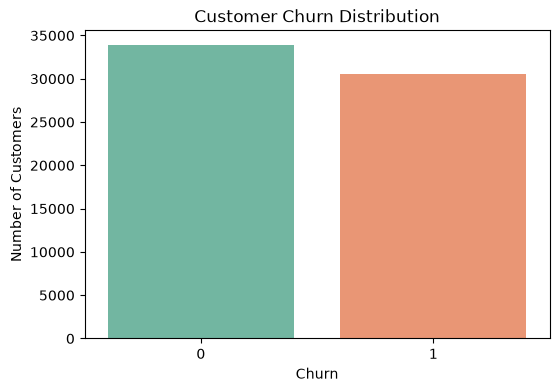

In [110]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Distribution of Numerical Columns

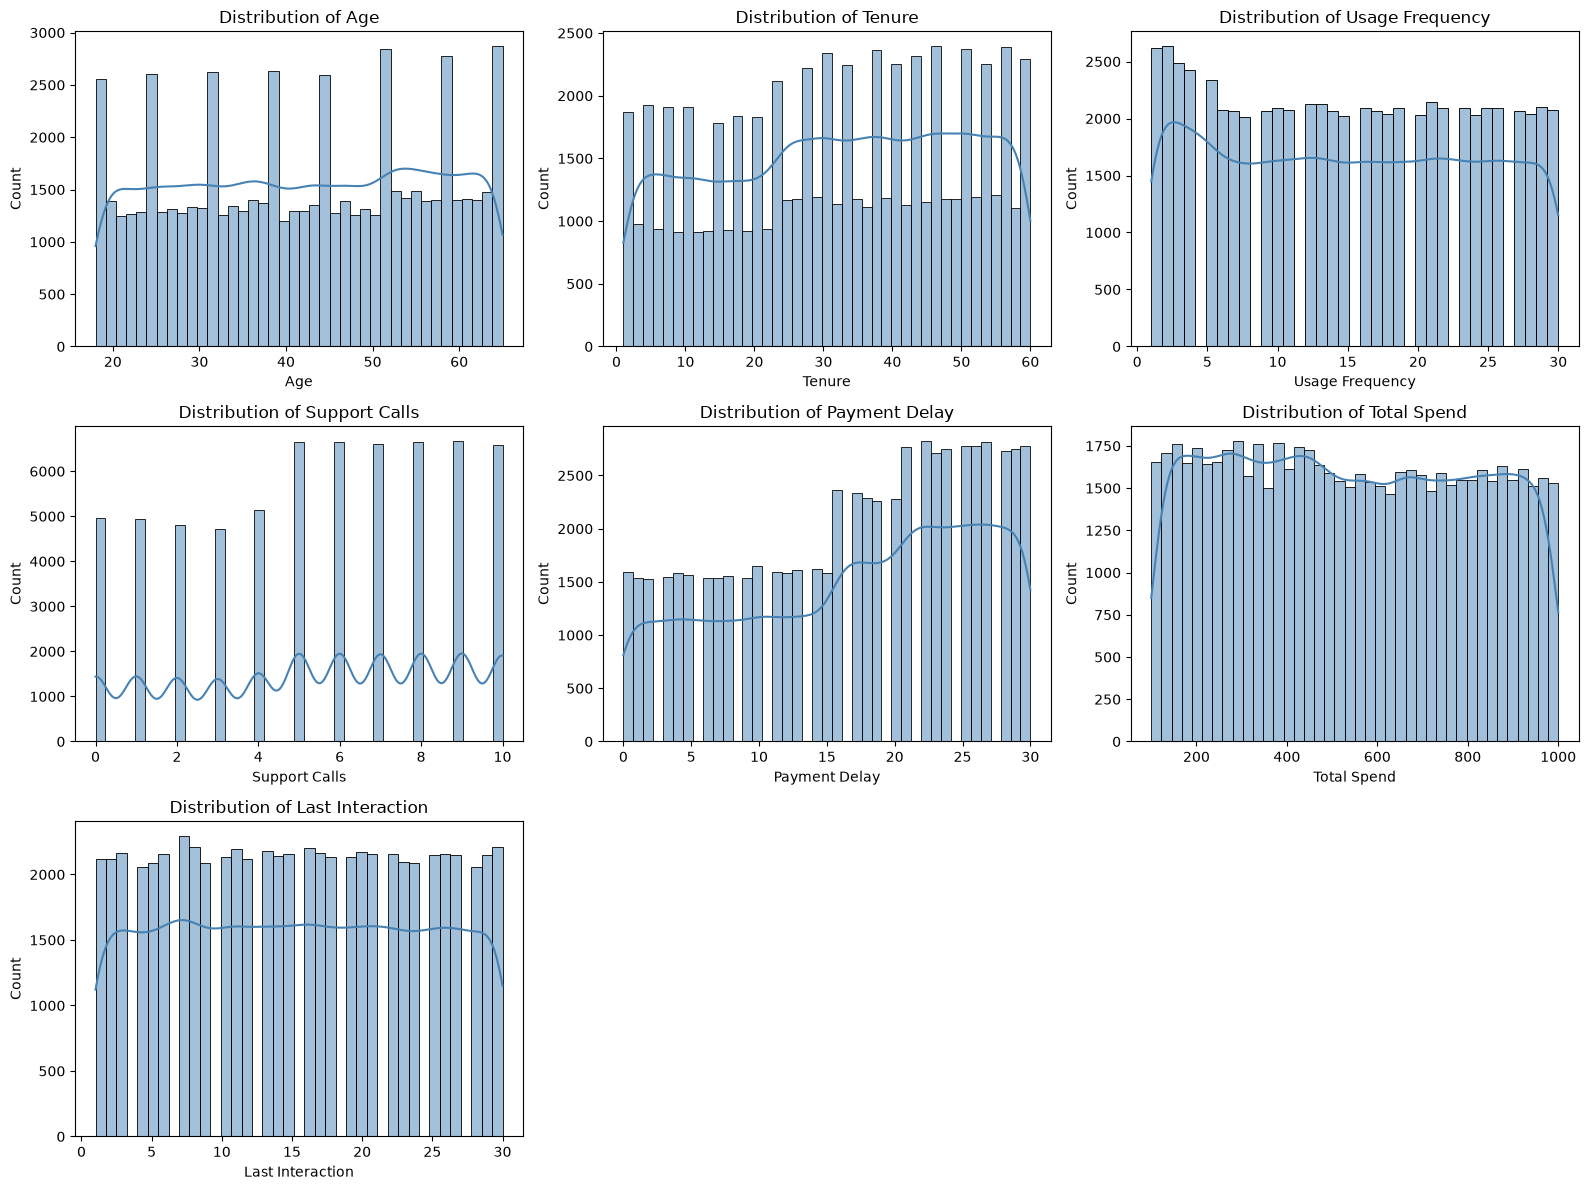

In [111]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### Boxplots for Numerical Columns

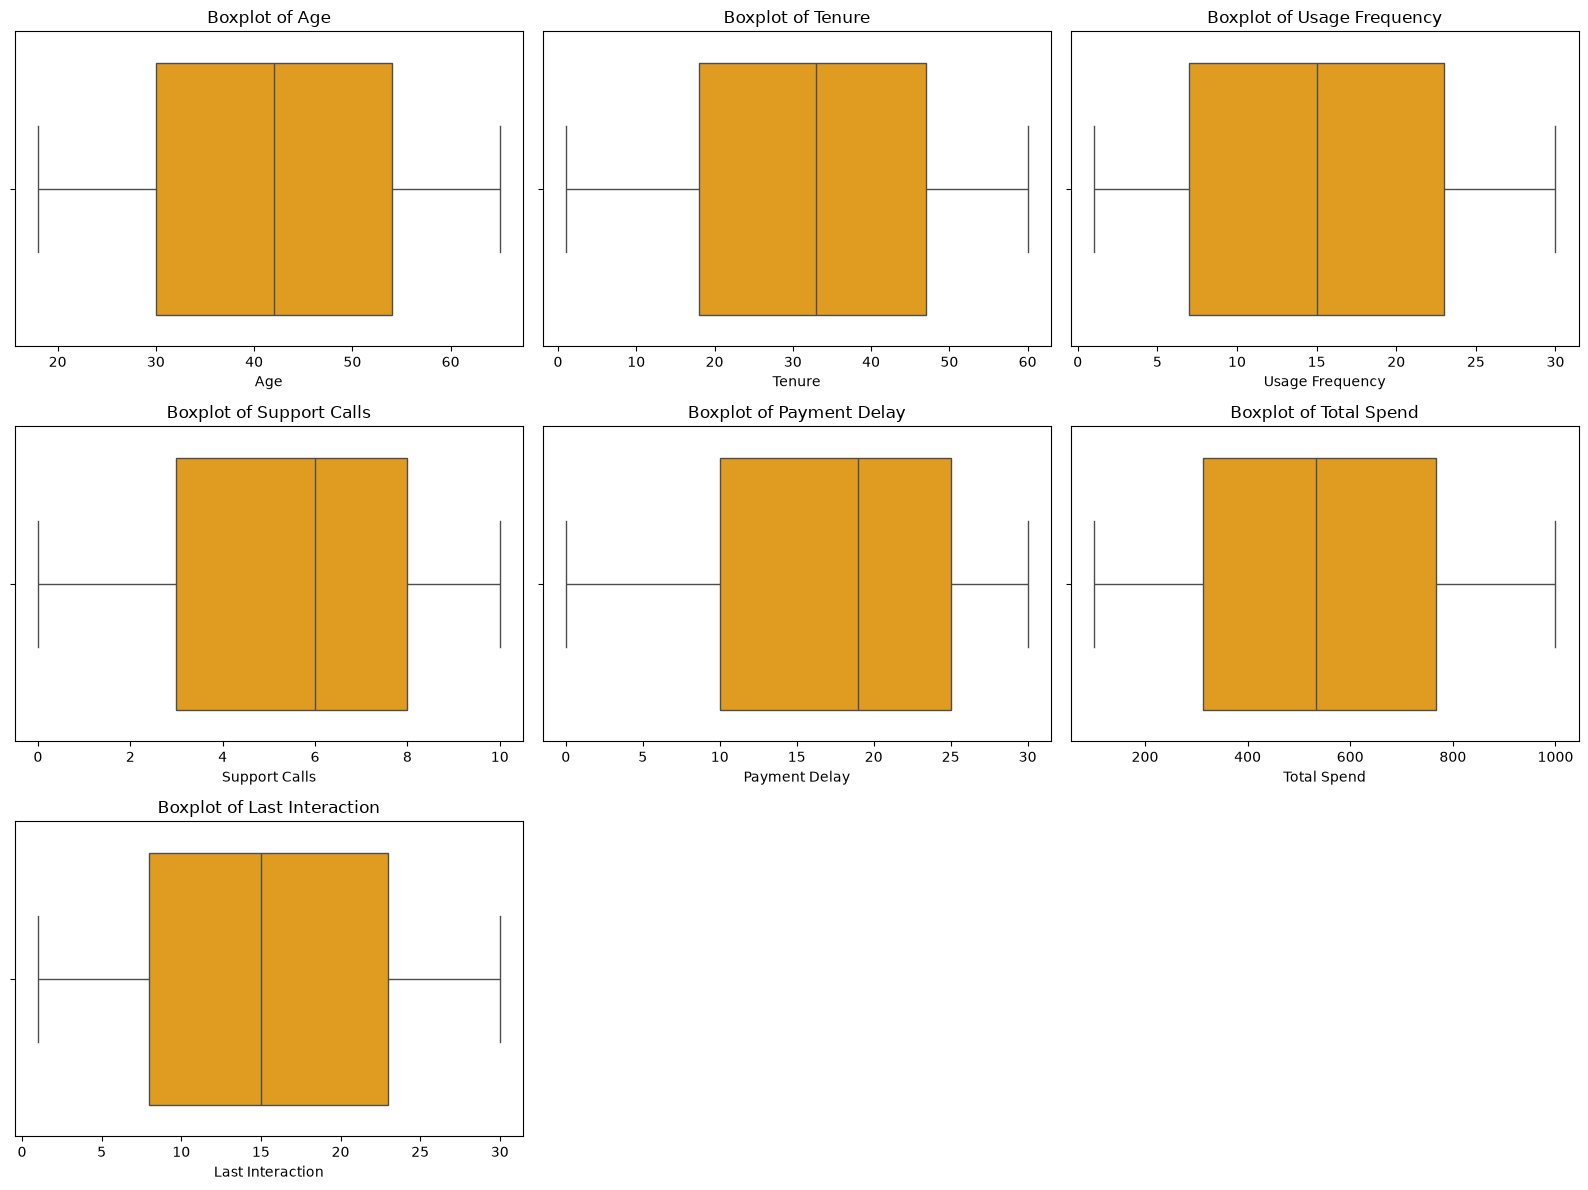

In [112]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df[col], ax=axes[i], color="orange")
    axes[i].set_title(f"Boxplot of {col}")
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### Correlation Heatmap

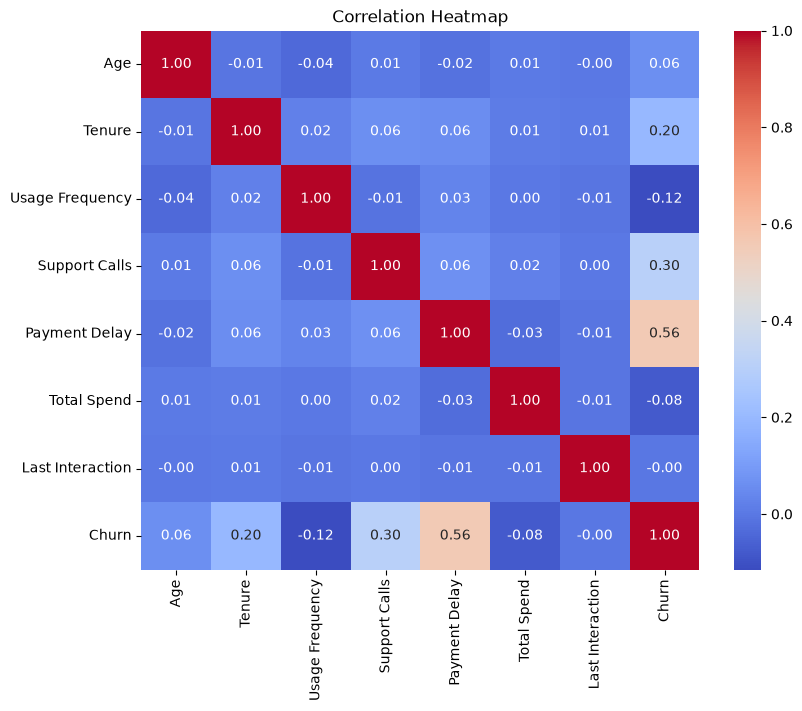

In [113]:
plt.figure(figsize=(9, 7))
corr = df[numerical_columns + ["Churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Churn Rate by Categorical Columns

C:\Users\MahraelAymanBekhetBa\AppData\Local\Temp\ipykernel_7704\2025857558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_cat.index, y=churn_by_cat.values, ax=axes[i], palette="viridis")
C:\Users\MahraelAymanBekhetBa\AppData\Local\Temp\ipykernel_7704\2025857558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_cat.index, y=churn_by_cat.values, ax=axes[i], palette="viridis")
C:\Users\MahraelAymanBekhetBa\AppData\Local\Temp\ipykernel_7704\2025857558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_cat

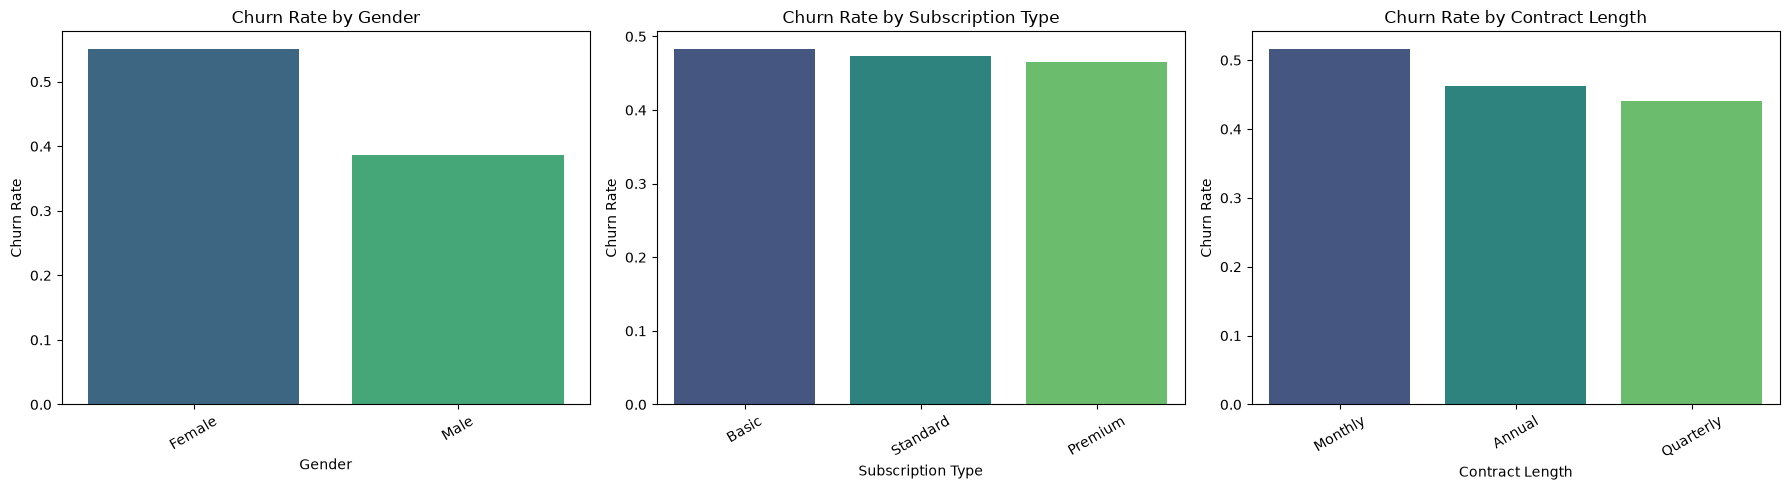

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_columns):
    churn_by_cat = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=churn_by_cat.index, y=churn_by_cat.values, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Encoding

In [115]:
df_encoded=pd.get_dummies(df , columns=categorical_columns,drop_first=True)
df_encoded.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22.0,25.0,14.0,4.0,27.0,598.0,9.0,1,False,False,False,True,False
1,41.0,28.0,28.0,7.0,13.0,584.0,20.0,0,False,False,True,True,False
2,47.0,27.0,10.0,2.0,29.0,757.0,21.0,0,True,True,False,False,False
3,35.0,9.0,12.0,5.0,17.0,232.0,18.0,0,True,True,False,False,True
4,53.0,58.0,24.0,9.0,2.0,533.0,18.0,0,False,False,True,False,False


In [116]:
X=df_encoded.drop(columns=["Churn"])
y=df_encoded["Churn"]

X.shape ,y.shape


((64374, 12), (64374,))

### Train/Test Split

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Churn ratio (train):", y_train.mean().round(3))
print("Churn ratio (test):", y_test.mean().round(3))

                                                

Train shape: (51499, 12)
Test shape: (12875, 12)
Churn ratio (train): 0.474
Churn ratio (test): 0.474


### Scaling

In [118]:
scaler = StandardScaler()

X_train[numerical_columns]=scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns]=scaler.transform(X_test[numerical_columns])

X_train.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
17402,1.002290,0.467698,-0.347864,-1.413220,-1.935572,0.728167,0.984201,False,False,True,True,False
20461,-0.289317,-0.117619,-1.254923,-0.448905,-0.918315,-1.387161,-1.100821,False,False,True,False,False
63787,-1.437413,-0.117619,0.672577,0.836848,0.211971,0.670685,-1.564159,True,True,False,False,True
12218,0.212974,-1.171191,1.239489,1.479724,-0.805286,1.759006,1.563374,True,True,False,True,False
6831,1.217558,0.292103,-0.234481,0.193971,0.551057,0.712838,-1.100821,False,False,True,False,True


## Model 1: LogisticRegression 

In [119]:
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

In [120]:
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_log))
print(classification_report(y_test, y_pred_log))

Accuracy : 0.8271844660194175
Precision: 0.8139384116693679
Recall   : 0.823413674372848
F1 Score : 0.8186486266199364
ROC AUC  : 0.9029984254294499
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



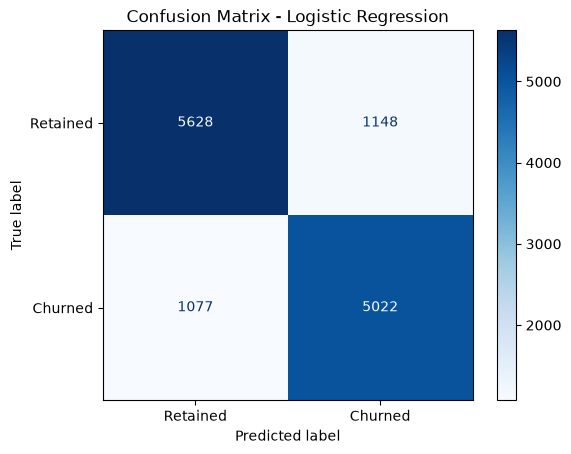

In [121]:
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Retained", "Churned"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

C:\Users\MahraelAymanBekhetBa\AppData\Local\Temp\ipykernel_7704\4138473444.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_log.values[:15], y=importances_log.index[:15], palette="Blues_r")


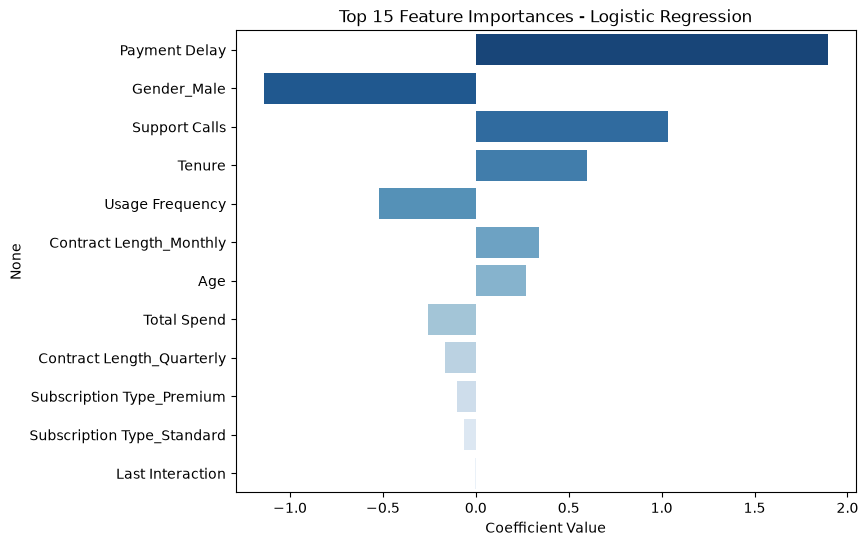

In [122]:
importances_log = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances_log.values[:15], y=importances_log.index[:15], palette="Blues_r")
plt.title("Top 15 Feature Importances - Logistic Regression")
plt.xlabel("Coefficient Value")
plt.show()

## Model 2: Random Forest

In [123]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [124]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9982135922330098
Precision: 0.9991784423266513
Recall   : 0.9970486965076242
F1 Score : 0.9981124333196553
ROC AUC  : 0.999989970194661
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



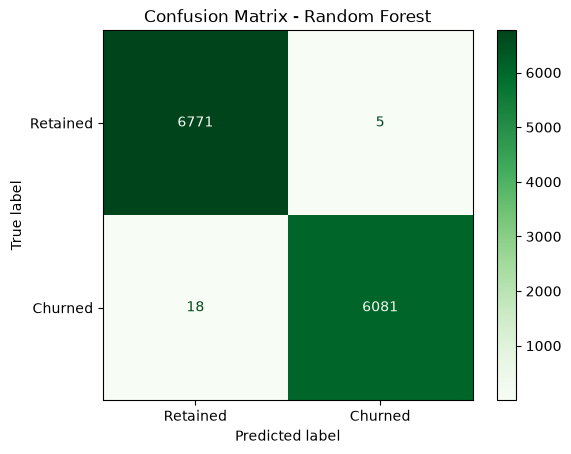

In [125]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Retained", "Churned"])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.show()

C:\Users\MahraelAymanBekhetBa\AppData\Local\Temp\ipykernel_7704\1782534967.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:15], y=importances.index[:15], palette="Greens_r")


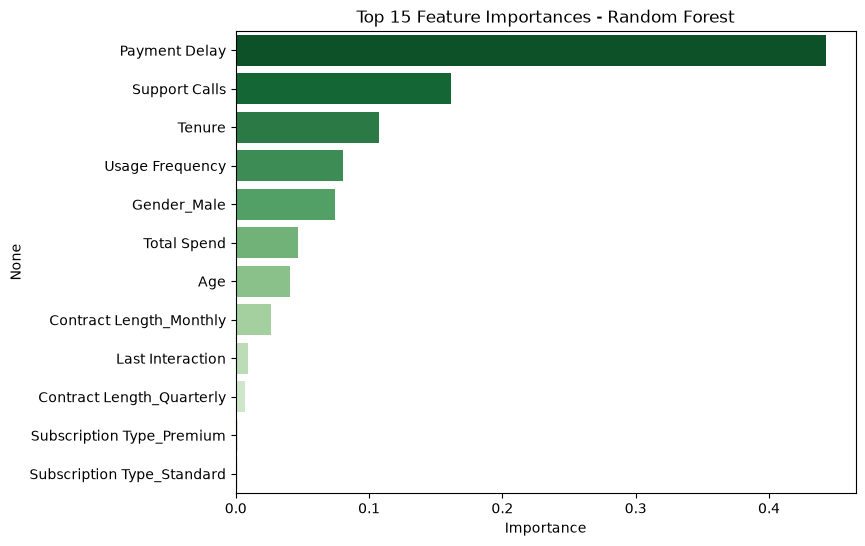

In [126]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette="Greens_r")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

## Model 3: XGBoost

In [127]:
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



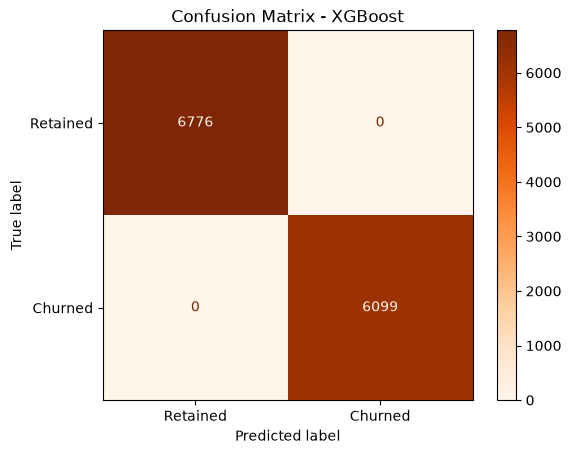

In [128]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Retained", "Churned"])
disp.plot(cmap="Oranges")
plt.title("Confusion Matrix - XGBoost")
plt.show()

C:\Users\MahraelAymanBekhetBa\AppData\Local\Temp\ipykernel_7704\977046863.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_xgb.values[:15], y=importances_xgb.index[:15], palette="Oranges_r")


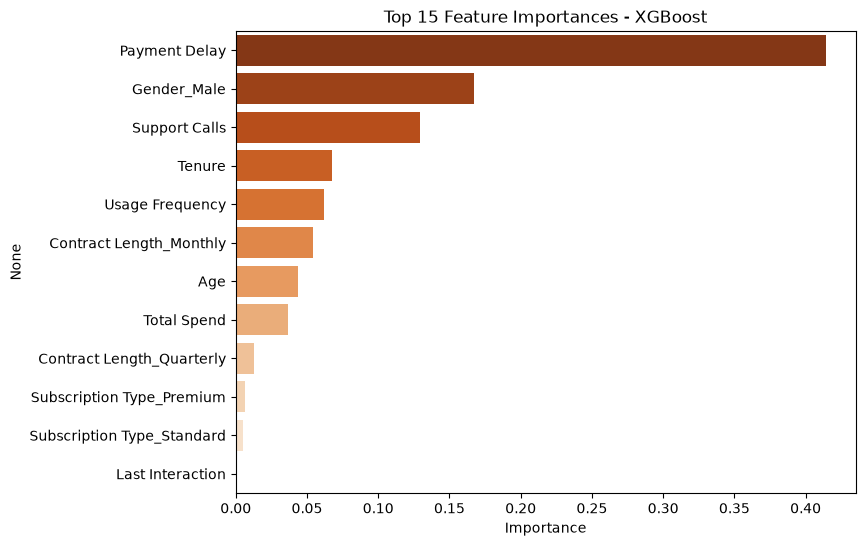

In [129]:
importances_xgb = pd.Series(xgb_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances_xgb.values[:15], y=importances_xgb.index[:15], palette="Oranges_r")
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.show()